## 환승역 편의시설 공급의 상대적 충분성 검토
### Paradox: *시설은 많지만 부하는 더 클 수 있음*
환승역은 비환승역보다 편의시설 수가 많겠지만, 무임 이용 부담도까지 고려하면 정말 충분할까?

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

import koreanize_matplotlib

from scipy.stats import mannwhitneyu

In [2]:
# 파일 불러오기
df = pd.read_csv('../../data/processed/team/subway_merged_base.csv')

# 원본 확인
print("데이터 크기:", df.shape)
print("컬럼 목록:", df.columns.tolist())
display(df.head())

# 필요한 컬럼만 확인
required_cols = ['지하철역', '호선명', '무임승하차', 'ES', 'EV']
missing_cols = [col for col in required_cols if col not in df.columns]

if missing_cols:
    raise ValueError(f"필수 컬럼이 없습니다: {missing_cols}")

데이터 크기: (244, 13)
컬럼 목록: ['지하철역', '호선명', '총승차인원', '무임승차인원', '총하차인원', '무임하차인원', '전체승하차', '무임승하차', '무임승하차비중', 'EV', 'ES', 'TOTAL', '시설부하지수']


,지하철역,호선명,총승차인원,무임승차인원,총하차인원,무임하차인원,전체승하차,무임승하차,무임승하차비중,EV,ES,TOTAL,시설부하지수
0,제기동,1,501317,269661,511782,290055,1013099,559716,55.25,3,2,5,39979.71
1,종각,1,1112527,151760,1083408,140929,2195935,292689,13.33,4,2,6,16260.50
2,종로5가,1,712905,247967,697910,240352,1410815,488319,34.61,3,0,3,40693.25
3,청량리,1,662997,280334,656727,281655,1319724,561989,42.58,2,6,8,40142.07
4,강남,2,2302759,161221,2246564,140970,4549323,302191,6.64,4,0,4,18886.94


In [3]:
# 가중치 계산 EV 4, ES 1
df['가중편의시설합'] = (df['EV'] * 4) + (df['ES'] * 1)

# 정렬
df_sorted = df.sort_values(by='시설부하지수', ascending=False).reset_index(drop=True)

# 순위 컬럼 추가
df_sorted['시설부하지수_순위'] = df_sorted['시설부하지수'].rank(method='first', ascending=False).astype(int)

# 상위 20% 역 추출
top_n = int(np.ceil(len(df_sorted) * 0.20))   # 49개
top_20_df = df_sorted.head(top_n).copy()

# 후보 여부 컬럼 추가
df_sorted['집중관리구역후보'] = False
df_sorted.loc[:top_n-1, '집중관리구역후보'] = True

print(f"전체 역 수: {len(df_sorted)}")
print(f"상위 20% 역 수: {top_n}")

전체 역 수: 244
상위 20% 역 수: 49


In [4]:
# 확인용 출력
display(
    df_sorted[['시설부하지수_순위', '지하철역', '호선명', '무임승하차', 'ES', 'EV', '가중편의시설합', '시설부하지수', '집중관리구역후보']].head(50)
)

,시설부하지수_순위,지하철역,호선명,무임승하차,ES,EV,가중편의시설합,시설부하지수,집중관리구역후보
0,1,종로5가,1,488319,0,3,12,40693.25,True
1,2,청량리,1,561989,6,2,14,40142.07,True
2,3,제기동,1,559716,2,3,14,39979.71,True
3,4,미아사거리,4,380795,2,2,10,38079.50,True
4,5,상계,4,261592,4,1,8,32699.00,True
5,6,선릉,2,440366,2,3,14,31454.71,True
6,7,회현,4,407309,6,2,14,29093.50,True
7,8,화곡,5,305281,4,2,12,25440.08,True
8,9,수유,4,399024,4,3,16,24939.00,True
9,10,홍제,3,291341,0,3,12,24278.42,True


In [13]:
top_20_df['집중관리구역후보'] = True

# 컬럼 정리
df_sorted_export = df_sorted[
    ['시설부하지수_순위', '지하철역', '호선명', '무임승하차', 'ES', 'EV', '가중편의시설합', '시설부하지수', '집중관리구역후보']
].copy()

top_20_export = top_20_df[
    ['시설부하지수_순위', '지하철역', '호선명', '무임승하차', 'ES', 'EV', '가중편의시설합', '시설부하지수', '집중관리구역후보']
].copy()

In [18]:
candidate_df = top_20_df.copy()

# 환승 여부 구분
candidate_df['환승여부'] = candidate_df['호선명'].astype(str).apply(
    lambda x: '환승역' if ',' in x else '비환승역'
)

# 요약표
q6_summary = candidate_df.groupby('환승여부').agg(
    역수=('지하철역', 'count'),
    평균_편의시설수=('TOTAL', 'mean'),
    중앙값_편의시설수=('TOTAL', 'median'),
    평균_가중편의시설합=('가중편의시설합', 'mean'),
    중앙값_가중편의시설합=('가중편의시설합', 'median'),
    평균_무임승하차=('무임승하차', 'mean'),
    중앙값_무임승하차=('무임승하차', 'median'),
    평균_시설부하지수=('시설부하지수', 'mean'),
    중앙값_시설부하지수=('시설부하지수', 'median')
).round(2)

display(q6_summary)

,역수,평균_편의시설수,중앙값_편의시설수,평균_가중편의시설합,중앙값_가중편의시설합,평균_무임승하차,중앙값_무임승하차,평균_시설부하지수,중앙값_시설부하지수
환승여부,,,,,,,,,
비환승역,40,7.05,7.0,15.52,14.5,305980.12,267049.0,20743.20,18502.75
환승역,9,17.44,16.0,33.44,33.0,554325.56,547114.0,16795.55,16579.21


In [23]:
# 검증용 데이터 분리
transfer = candidate_df[candidate_df['환승여부'] == '환승역']
non_transfer = candidate_df[candidate_df['환승여부'] == '비환승역']

# Mann-Whitney U 검정
q6_test_results = []
for col, label in [
    ('TOTAL', '편의시설수'),
    ('가중편의시설합', '가중편의시설합'),
    ('무임승하차', '무임승하차'),
    ('시설부하지수', '시설부하지수')
]:
    stat, p = mannwhitneyu(transfer[col], non_transfer[col], alternative='two-sided')
    q6_test_results.append({
        '지표': label,
        '환승역_평균': round(transfer[col].mean(), 2),
        '비환승역_평균': round(non_transfer[col].mean(), 2),
        '환승역_중앙값': round(transfer[col].median(), 2),
        '비환승역_중앙값': round(non_transfer[col].median(), 2),
        'p-value': round(p, 6)
    })

q6_test_df = pd.DataFrame(q6_test_results)
display(q6_test_df)

,지표,환승역_평균,비환승역_평균,환승역_중앙값,비환승역_중앙값,p-value
0,편의시설수,17.44,7.05,16.00,7.00,0.000094
1,가중편의시설합,33.44,15.52,33.00,14.50,0.000019
2,무임승하차,554325.56,305980.12,547114.00,267049.00,0.000234
3,시설부하지수,16795.55,20743.20,16579.21,18502.75,0.261367


In [32]:
candidate_df = top_20_df.copy()

# 환승 여부 구분
candidate_df['환승여부'] = candidate_df['호선명'].astype(str).apply(
    lambda x: '환승역' if ',' in x else '비환승역'
)

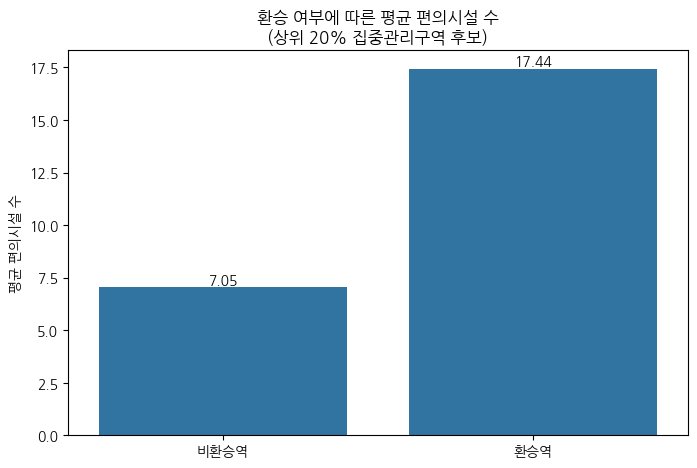

In [31]:
# 평균 편의시설 수 비교
plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=candidate_df,
    x='환승여부',
    y='TOTAL',
    estimator=np.mean,
    errorbar=None
)
plt.title('환승 여부에 따른 평균 편의시설 수\n(상위 20% 집중관리구역 후보)')
plt.xlabel('')
plt.ylabel('평균 편의시설 수')

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.2f}',
                (p.get_x() + p.get_width()/2, height),
                ha='center', va='bottom', fontsize=10)

plt.show()

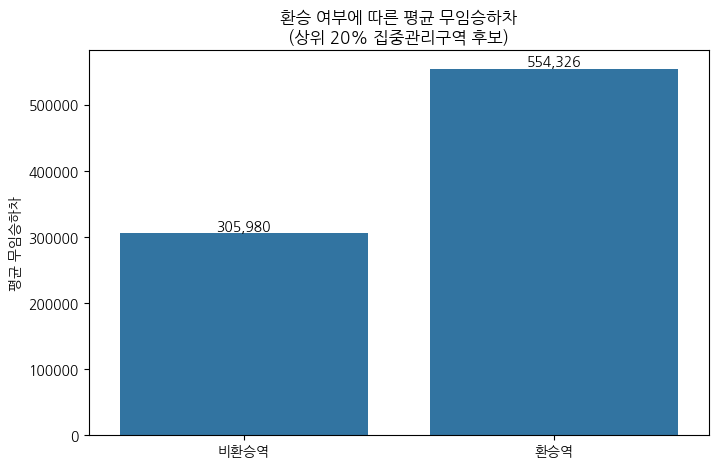

In [28]:
# 평균 무임승하차 비교
plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=candidate_df,
    x='환승여부',
    y='무임승하차',
    estimator=np.mean,
    errorbar=None
)
plt.title('환승 여부에 따른 평균 무임승하차\n(상위 20% 집중관리구역 후보)')
plt.xlabel('')
plt.ylabel('평균 무임승하차')

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:,.0f}',
                (p.get_x() + p.get_width()/2, height),
                ha='center', va='bottom', fontsize=10)

plt.show()

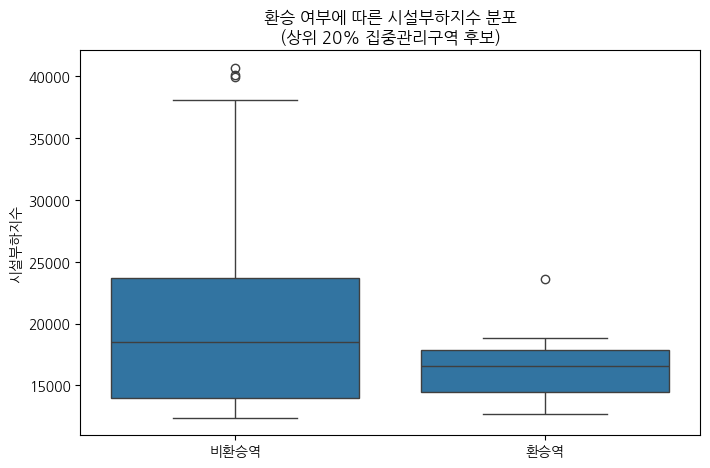

In [30]:
# 시설부하지수 분포 비교
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=candidate_df,
    x='환승여부',
    y='시설부하지수'
)
plt.title('환승 여부에 따른 시설부하지수 분포\n(상위 20% 집중관리구역 후보)')
plt.xlabel('')
plt.ylabel('시설부하지수')
plt.show()